# 03 — Data Augmentation
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Load preprocessed arrays from `data/X.npy` and `data/y.npy`
- Split into train / validation sets (stratified)
- Configure and visualise data augmentation
- Save split arrays for use in training notebooks

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.config import DATA_DIR, IMG_SIZE
from src.data_loader import split_dataset, build_augmentation_generator

2026-02-28 01:31:28.419400: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 01:31:28.450996: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 01:31:29.508661: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 01:31:39.404439: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

## 1. Load Preprocessed Arrays

In [2]:
X = np.load(os.path.join(DATA_DIR, "X.npy"))
y = np.load(os.path.join(DATA_DIR, "y.npy"))

print(f"X : {X.shape}  dtype={X.dtype}")
print(f"y : {y.shape}  classes={len(np.unique(y))}")

X : (39209, 64, 64, 3)  dtype=float32
y : (39209,)  classes=43


## 2. Train / Validation Split

In [3]:
X_train, X_val, y_train, y_val = split_dataset(X, y)

# Save splits
np.save(os.path.join(DATA_DIR, "X_train.npy"), X_train)
np.save(os.path.join(DATA_DIR, "X_val.npy"),   X_val)
np.save(os.path.join(DATA_DIR, "y_train.npy"), y_train)
np.save(os.path.join(DATA_DIR, "y_val.npy"),   y_val)
print("Split arrays saved to data/")

Train :  31367 images
Val   :   7842 images
Split arrays saved to data/


## 3. Configure Data Augmentation

In [4]:
datagen = build_augmentation_generator()
datagen.fit(X_train)
print("Augmentation generator ready.")

Augmentation generator ready.


## 4. Visualise Augmented Images

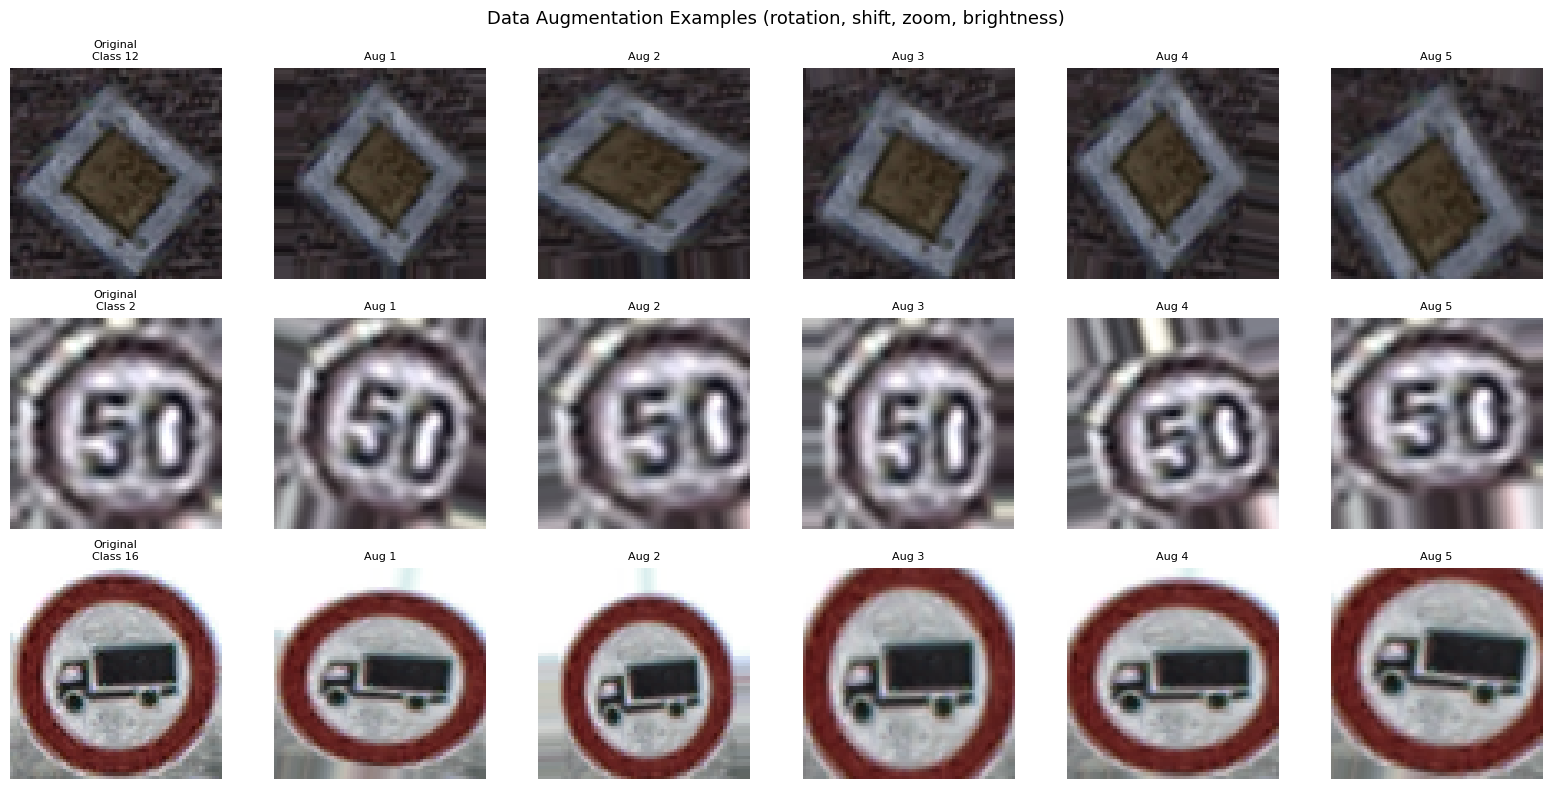

In [5]:
# Pick 3 different original images and show 5 augmented versions each
sample_indices = [0, 1000, 5000]

fig, axes = plt.subplots(len(sample_indices), 6, figsize=(16, 8))

for row_idx, src_idx in enumerate(sample_indices):
    orig = X_train[src_idx:src_idx+1]
    label = y_train[src_idx]

    # Original
    axes[row_idx, 0].imshow(orig[0])
    axes[row_idx, 0].set_title(f'Original\nClass {label}', fontsize=8)
    axes[row_idx, 0].axis('off')

    # 5 augmented
    for col_idx, batch in enumerate(datagen.flow(orig, batch_size=1)):
        if col_idx >= 5:
            break
        axes[row_idx, col_idx + 1].imshow(batch[0])
        axes[row_idx, col_idx + 1].set_title(f'Aug {col_idx + 1}', fontsize=8)
        axes[row_idx, col_idx + 1].axis('off')

plt.suptitle('Data Augmentation Examples (rotation, shift, zoom, brightness)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 5. Class Distribution — Train vs Validation

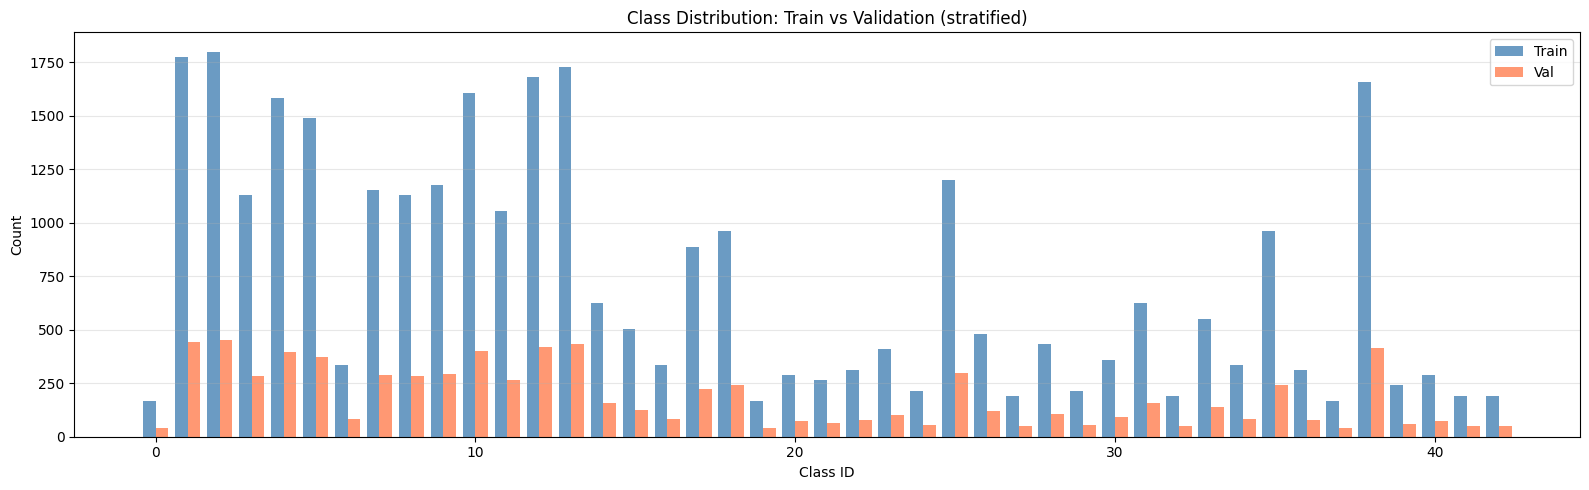

In [6]:
import numpy as np
import matplotlib.pyplot as plt

train_counts = np.bincount(y_train, minlength=43)
val_counts   = np.bincount(y_val,   minlength=43)
x = np.arange(43)
w = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - w/2, train_counts, w, label='Train', color='steelblue', alpha=0.8)
ax.bar(x + w/2, val_counts,   w, label='Val',   color='coral',     alpha=0.8)
ax.set_xlabel('Class ID')
ax.set_ylabel('Count')
ax.set_title('Class Distribution: Train vs Validation (stratified)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()